In [ ]:
# Track ArUco markers

import cv2
import cv2.aruco as aruco
import numpy as np
import json

# Load the camera calibration parameters from './calibration_data.json'
with open('./calibration_data.json', 'r') as f:
    calibration_data = json.load(f)
    camera_matrix = np.array(calibration_data['camera_matrix'])
    dist_coeffs = np.array(calibration_data['distortion_coefficients'])

# Define the ArUco dictionary and parameters
aruco_dict = aruco.getPredefinedDictionary(aruco.DICT_4X4_50)
parameters = aruco.DetectorParameters()

# Create detector
detector = aruco.ArucoDetector(aruco_dict, parameters)

def get_obj_points(marker_length):
    return np.array([[-marker_length/2, marker_length/2, 0],
                     [marker_length/2, marker_length/2, 0],
                     [marker_length/2, -marker_length/2, 0],
                     [-marker_length/2, -marker_length/2, 0]], dtype=np.float32)

inch_to_meter = 0.0254

# Marker length for world frame
w_marker_length = (5 + 12/16) * inch_to_meter 
w_obj_points = get_obj_points(w_marker_length)

# Marker length for robot
r_marker_length = (3 + 13/16) * inch_to_meter
r_obj_points = get_obj_points(r_marker_length)

world_marker_ids = [0, 1, 2]


In [110]:
# Capture a frame from the camera and detect ArUco markers
from asyncio import sleep
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(0)  # Use 0 for default camera
if not cap.isOpened():
    print("Cannot open camera")
    exit()

state_list = []

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Failed to capture frame")
            break

        frame = cv2.undistort(frame, camera_matrix, dist_coeffs)
        # frame = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)

        # Detect markers
        corners, ids, rejected = detector.detectMarkers(frame)

        if ids is not None:
            ids = ids.flatten()
            aruco.drawDetectedMarkers(frame, corners, ids)

            world_coordinates = {}
            world_corners = {}
            for i in range(len(ids)):
                if ids[i] in world_marker_ids:
                    # Use solvePnP with all four corners of the marker
                    success, rvec, tvec = cv2.solvePnP(w_obj_points, corners[i], camera_matrix, dist_coeffs)
                    if success:
                        # Use the first corner of the detected marker for world coordinates
                        # corners[i][0][0] is the first corner (x, y) in image coordinates
                        # Project the first corner to world coordinates using the transformation
                        # tvec is the translation vector for the marker center, but we want the first corner
                        # Transform the first corner from object points to camera coordinates
                        first_corner_obj = w_obj_points[0].reshape(1, 3)
                        first_corner_cam, _ = cv2.projectPoints(first_corner_obj, rvec, tvec, camera_matrix, dist_coeffs)
                        # For world coordinates, use solvePnP result and add the offset from the marker center to the first corner
                        # But since solvePnP gives the pose for the marker, we can transform the first corner using the pose
                        R, _ = cv2.Rodrigues(rvec)
                        first_corner_world = R @ w_obj_points[0] + tvec.flatten()
                        world_coordinates[ids[i]] = first_corner_world
                        world_corners[ids[i]] = corners[i][0][0]

                        # Draw the first corner
                        cv2.circle(frame, tuple(corners[i][0][0].astype(int)), 5, (0, 255, 0), -1)
                        cv2.putText(frame, f"ID: {ids[i]}", tuple(corners[i][0][0].astype(int) + np.array([10, 10])), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

            if all(marker in world_coordinates for marker in world_marker_ids):
                # Define the world frame transformation using the first corners
                origin = world_coordinates[0]
                x_axis = world_coordinates[2] - origin  # 0 to 2 is x-axis
                y_axis = world_coordinates[1] - origin  # 0 to 1 is y-axis

                # Orthogonalize and normalize axes
                x_axis = x_axis / np.linalg.norm(x_axis)

                if not np.isclose(np.dot(x_axis, y_axis), 0, atol=1e-2):
                    angle = np.degrees(np.arccos(np.dot(x_axis, y_axis) / (np.linalg.norm(x_axis) * np.linalg.norm(y_axis))))
                    print(f"Angle between x and y axes: {angle:.2f} degrees.")

                proj = np.dot(y_axis, x_axis) * x_axis
                y_axis = y_axis - proj

                y_axis = y_axis / np.linalg.norm(y_axis)
                z_axis = np.cross(x_axis, y_axis)
                z_axis = z_axis / np.linalg.norm(z_axis)

                # Construct rotation matrix
                rotation_matrix = np.vstack([x_axis, y_axis, z_axis]).T
                translation_vector = origin

                # Create a 4x4 homogeneous transformation matrix
                world_to_camera_transform = np.eye(4)
                world_to_camera_transform[:3, :3] = rotation_matrix
                world_to_camera_transform[:3, 3] = translation_vector

                # print("World to camera transformation matrix:", world_to_camera_transform)

            # Draw axis for markers other than world markers
            for i in range(len(ids)):
                if ids[i] not in world_marker_ids and all(marker in world_coordinates for marker in world_marker_ids):
                    success, rvec, tvec = cv2.solvePnP(r_obj_points, corners[i], camera_matrix, dist_coeffs)
                    if success:
                        cv2.drawFrameAxes(frame, camera_matrix, dist_coeffs, rvec, tvec, 0.1)
                        # Transform rvec and tvec to world coordinates
                        camera_to_marker_transform = np.eye(4)
                        camera_to_marker_transform[:3, :3] = cv2.Rodrigues(rvec)[0]
                        camera_to_marker_transform[:3, 3] = tvec.flatten()

                        marker_in_world = np.dot(np.linalg.inv(world_to_camera_transform), camera_to_marker_transform)
                        # print(f"Marker {ids[i]} in world frame:", marker_in_world)

                        # print x, y, theta of the marker in world frame
                        y_world = marker_in_world[0, 3]
                        x_world = marker_in_world[1, 3]
                        theta_world = np.arctan2(marker_in_world[1, 0], marker_in_world[0, 0])
                        state_list.append([x_world, y_world, theta_world])

                        print(f"Marker {ids[i]} in world frame: x={x_world:.2f} m, y={y_world:.2f} m, theta={np.degrees(theta_world):.2f} degrees")

        cv2.imshow('frame', frame)

        sleep(0.5)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
except KeyboardInterrupt:
    print("Exiting...")
finally:
    cap.release()
    cv2.destroyAllWindows()

Angle between x and y axes: 91.66 degrees.
Marker 7 in world frame: x=0.20 m, y=0.58 m, theta=-179.84 degrees
Angle between x and y axes: 91.58 degrees.
Marker 7 in world frame: x=0.20 m, y=0.58 m, theta=-179.41 degrees
Angle between x and y axes: 91.63 degrees.
Marker 7 in world frame: x=0.20 m, y=0.58 m, theta=-179.88 degrees


/var/folders/mh/4_lxl3vj0fvfk7d2dk2ss6nc0000gn/T/ipykernel_83280/2611620866.py:109: RuntimeWarning: coroutine 'sleep' was never awaited
  sleep(0.5)


Angle between x and y axes: 91.58 degrees.
Marker 7 in world frame: x=0.20 m, y=0.58 m, theta=-179.93 degrees
Angle between x and y axes: 91.62 degrees.
Marker 7 in world frame: x=0.20 m, y=0.58 m, theta=-179.88 degrees
Angle between x and y axes: 91.60 degrees.
Marker 7 in world frame: x=0.20 m, y=0.58 m, theta=-179.91 degrees
Angle between x and y axes: 91.58 degrees.
Marker 7 in world frame: x=0.20 m, y=0.58 m, theta=-179.93 degrees
Angle between x and y axes: 91.58 degrees.
Marker 7 in world frame: x=0.20 m, y=0.58 m, theta=-179.93 degrees
Angle between x and y axes: 91.58 degrees.
Marker 7 in world frame: x=0.20 m, y=0.58 m, theta=-179.98 degrees
Angle between x and y axes: 91.65 degrees.
Marker 7 in world frame: x=0.20 m, y=0.58 m, theta=-179.82 degrees
Angle between x and y axes: 91.63 degrees.
Marker 7 in world frame: x=0.20 m, y=0.58 m, theta=-179.93 degrees
Angle between x and y axes: 91.40 degrees.
Marker 7 in world frame: x=0.20 m, y=0.59 m, theta=-179.52 degrees
Angle betw

In [111]:
# Calculate variance of x, y, theta
state_array = np.array(state_list)
print("Samples", len(state_array))
print()

x_variance = np.var(state_array[:, 0])
y_variance = np.var(state_array[:, 1])
theta_variance = np.var(state_array[:, 2])

print(f"Variance of x: {x_variance:.6f} m^2")
print(f"Variance of y: {y_variance:.6f} m^2")
print(f"Variance of theta: {theta_variance:.6f} rad^2")
print()

Q = np.cov(state_array, rowvar=False)
print("Covariance matrix Q:")
print(Q)
print()



# Mean of x, y, theta
x_mean = np.mean(state_array[:, 0])
y_mean = np.mean(state_array[:, 1])
theta_mean = np.mean(state_array[:, 2])

# print(f"Mean of x: {x_mean:.6f} m")
# print(f"Mean of y: {y_mean:.6f} m")
# print(f"Mean of theta: {theta_mean:.6f} rads")

# Inch and degree
print(f"Mean of x: {x_mean / inch_to_meter:.6f} inches")
print(f"Mean of y: {y_mean / inch_to_meter:.6f} inches")
print(f"Mean of theta: {np.degrees(theta_mean):.6f} degrees")

Samples 249

Variance of x: 0.000001 m^2
Variance of y: 0.000000 m^2
Variance of theta: 5.409807 rad^2

Covariance matrix Q:
[[1.31469634e-06 1.07275353e-07 1.08102805e-03]
 [1.07275353e-07 2.82102429e-07 5.17560645e-04]
 [1.08102805e-03 5.17560645e-04 5.43162098e+00]]

Mean of x: 7.715031 inches
Mean of y: 23.003869 inches
Mean of theta: -119.833027 degrees


In [109]:
measured_x     = np.array([22.19, 23.90, 36.30, 27.27, 29.57, 15.09, 26.45, 27.76])
ground_truth_x = np.array([22.00, 20.00, 34.50, 27.00, 25.50, 11.00, 23.50, 26.00])

measured_y     = np.array([02.70, 22.42, 25.78, 20.55, 25.54, 25.98, 25.60, 18.62])
ground_truth_y = np.array([03.50, 25.00, 27.50, 23.00, 27.00, 25.50, 23.50, 20.50])

measured_theta     = np.array([92.80, 00.23, 90.42, 44.75, -44.58, -49.40, -90.99, -133.39])
ground_truth_theta = np.array([90.00, 00.00, 90.00, 45.00, -45.00, -41.00, -90.00, -135.00])

# x_variance = np.var(measured_x - ground_truth_x)
# y_variance = np.var(measured_y - ground_truth_y)
# theta_variance = np.var(measured_theta - ground_truth_theta)

# print(f"Variance of x error: {x_variance:.6f} in^2")
# print(f"Variance of y error: {y_variance:.6f} in^2")
# print(f"Variance of theta error: {theta_variance:.6f} deg^2")

errors = np.vstack([
    measured_x - ground_truth_x,
    measured_y - ground_truth_y,
    measured_theta - ground_truth_theta
])

Q = np.cov(errors, ddof=1)

print("Covariance matrix Q:")
print(Q)
print()

error_x = measured_x - ground_truth_x
error_y = measured_y - ground_truth_y
error_theta = measured_theta - ground_truth_theta

errors = np.vstack([error_x, error_y, error_theta])
Q_t = np.cov(errors, ddof=1)
print(Q_t)

Covariance matrix Q:
[[ 2.62635536  0.67187321 -2.96005714]
 [ 0.67187321  2.56166964 -2.43078571]
 [-2.96005714 -2.43078571 11.46817143]]

[[ 2.62635536  0.67187321 -2.96005714]
 [ 0.67187321  2.56166964 -2.43078571]
 [-2.96005714 -2.43078571 11.46817143]]


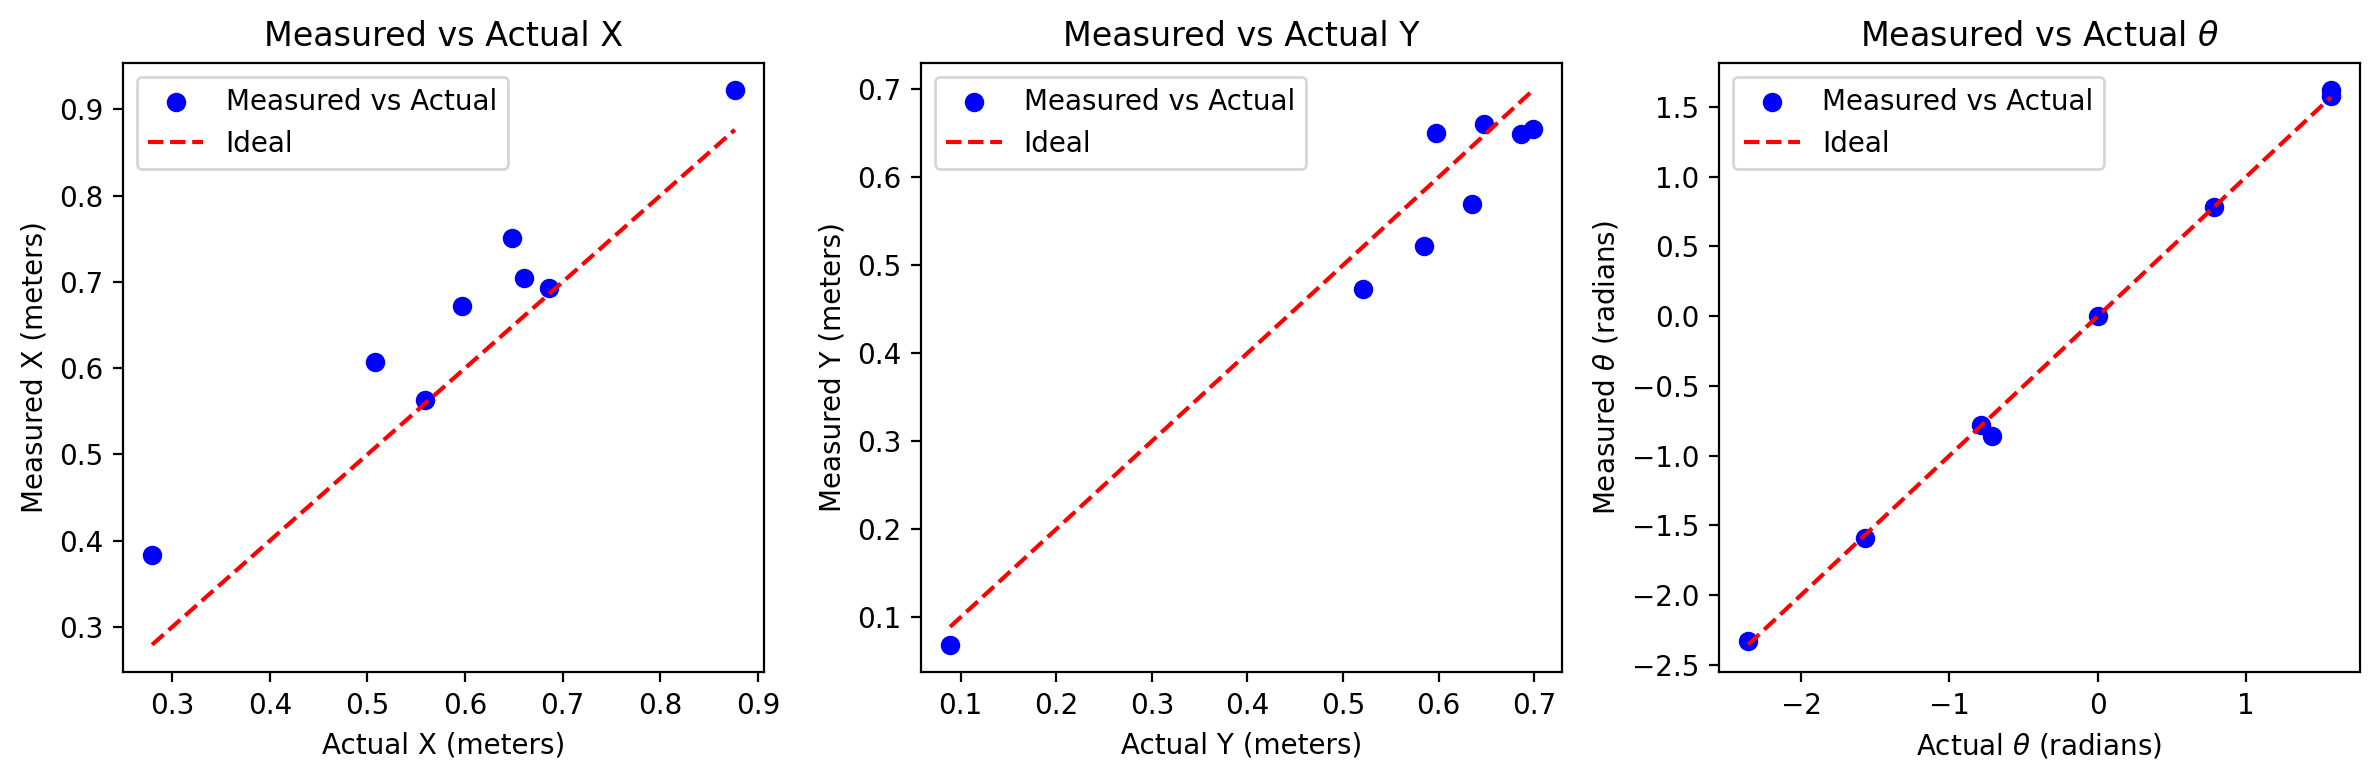

In [108]:
# Convert to SI units
measured_x_si = measured_x * inch_to_meter
ground_truth_x_si = ground_truth_x * inch_to_meter
measured_y_si = measured_y * inch_to_meter
ground_truth_y_si = ground_truth_y * inch_to_meter
measured_theta_si = np.radians(measured_theta)
ground_truth_theta_si = np.radians(ground_truth_theta)

# Plotting measured vs actual
plt.figure(figsize=(12, 4), dpi=200)
plt.subplot(1, 3, 1)
plt.scatter(ground_truth_x_si, measured_x_si, label='Measured vs Actual', color='blue')
plt.plot([min(ground_truth_x_si), max(ground_truth_x_si)], [min(ground_truth_x_si), max(ground_truth_x_si)], 'r--', label='Ideal')
plt.xlabel('Actual X (meters)')
plt.ylabel('Measured X (meters)')
plt.title('Measured vs Actual X')
plt.legend()    
plt.subplot(1, 3, 2)
plt.scatter(ground_truth_y_si, measured_y_si, label='Measured vs Actual', color='blue')
plt.plot([min(ground_truth_y_si), max(ground_truth_y_si)], [min(ground_truth_y_si), max(ground_truth_y_si)], 'r--', label='Ideal')
plt.xlabel('Actual Y (meters)')
plt.ylabel('Measured Y (meters)')
plt.title('Measured vs Actual Y')
plt.legend()
plt.subplot(1, 3, 3)
plt.scatter(ground_truth_theta_si, measured_theta_si, label='Measured vs Actual', color='blue')
plt.plot([min(ground_truth_theta_si), max(ground_truth_theta_si)], [min(ground_truth_theta_si), max(ground_truth_theta_si)], 'r--', label='Ideal')
plt.xlabel(r'Actual $\theta$ (radians)')
plt.ylabel(r'Measured $\theta$ (radians)')
plt.title(r'Measured vs Actual $\theta$')
plt.legend()
plt.tight_layout()
plt.show()